# Vector representations of words: encoding lexical semantics

## 🔍 Where does it start?

In NLP, the basic unit is a **word**.

But a word as text (ASCII/Unicode string) only tells the computer **how it looks**, not **what it means**.

We need a way to represent words as **numbers** so that a model can:

* compare words
* combine meanings
* measure similarity
* learn semantic relationships

---

## 🧱 One-hot encoding — the first idea

Suppose our vocabulary has (|V| = 10{,}000) words.

We can represent each word as a vector of length 10,000:

$
[0, 0, \dots, 1, \dots, 0]
$

The position of `1` identifies the word.

### Problems with one-hot vectors

* ❌ No notion of similarity:
  `cat` and `tiger` are as different as `cat` and `carburetor`
* ❌ Extremely sparse and memory-inefficient
* ❌ Vector size grows with vocabulary
* ❌ No way to learn meaning from this representation

> One-hot vectors encode **identity**, not **semantics**.

---

## 💡 Idea: learn dense vectors that capture meaning

What if instead of huge sparse vectors, we learned **small dense vectors** like:

$
\text{cat} \rightarrow [0.21, -0.44, 0.88, \dots]
$

Such vectors could capture:

* semantic similarity
* syntactic roles
* relationships between words

This is the idea behind **word embeddings**.

And one of the first and most influential methods to learn them is **Word2Vec**.

---

## 🧠 Distributional hypothesis (the key idea)

> “You shall know a word by the company it keeps.” — J. R. Firth

Words that appear in **similar contexts** tend to have **similar meanings**.

This simple idea is the foundation of Word2Vec.


## 🧠 Why semantic similarity matters

Assume the model has seen:

* *A mathematician reads a scientific article.*
* *A physicist reads a scientific article.*
* *A mathematician prepares a conference paper.*

Now it sees a new sentence:

* *A physicist prepares a conference paper.*

Even if this exact sentence never appeared, we want the model to **generalize**:

* `mathematician` and `physicist` appear in similar contexts
* what is true for one is likely true for the other

This ability to generalize from context is **semantic similarity**.

> Words are similar not because they look alike, but because they **behave alike in language**.

This directly follows the **distributional hypothesis** introduced earlier.

---

## 🧭 Semantic space intuition

Imagine every word is a point in a high-dimensional space of hidden semantic features:

$
q_{\text{mathematician}} = [2.3, 9.4, -5.5, \dots]
$
$
q_{\text{physicist}} = [2.5, 9.1, 6.4, \dots]
$

We do **not** define what each coordinate means.
The model learns this automatically from data.

Words used in similar contexts end up **close to each other** in this space.

---

## 📏 Measuring similarity

To measure how close two words are, we use **cosine similarity**:

$
\text{sim}(a,b) =
\frac{q_a \cdot q_b}{|q_a| |q_b|}
$

* cosine ≈ 1 → very similar
* cosine ≈ 0 → unrelated
* cosine ≈ −1 → opposite

This is the standard metric for word embeddings.

---

## 🔁 One-hot vs Embeddings

| One-hot encoding            | Word embeddings                     |
| --------------------------- | ----------------------------------- |
| Huge, sparse vectors        | Small, dense vectors (100–300 dims) |
| Encode only identity        | Encode semantic meaning             |
| No similarity between words | Similar words have similar vectors  |
| Cosine similarity = 0       | Cosine similarity is meaningful     |

---

## 🤖 How do we get such vectors?

We **do not** manually design features.

Instead:

> Word vectors are **learned as model parameters** during training.

Their dimensions are not directly interpretable, but their **geometry** captures meaning.

This is exactly what **Word2Vec** learns.

---

## 📚 Word2Vec (preview)

Word2Vec is a family of simple neural models that learn word embeddings from large text corpora using the distributional hypothesis.

Key papers:

* [Mikolov et al., *Efficient Estimation of Word Representations in Vector Space* (2013)](https://arxiv.org/pdf/1301.3781)
* [Mikolov et al., *Distributed Representations of Words and Phrases and their Compositionality* (2013)](https://proceedings.neurips.cc/paper_files/paper/2013/file/9aa42b31882ec039965f3c4923ce901b-Paper.pdf)

Next, we will see **how Word2Vec actually learns** these vectors.


## 🔎 First look at embeddings in PyTorch

This small example shows what an **embedding layer** really is: a **trainable lookup table** that maps word indices to dense vectors.


In [4]:
import torch                      # main PyTorch library
import torch.nn as nn             # neural network layers (Embedding lives here)

# Fix random seed so results are reproducible
torch.manual_seed(1)

# Our tiny vocabulary: map each word to a unique index (like one-hot positions)
word_to_ix = {"hello": 0, "world": 1}

# Create an embedding layer:
# nn.Embedding(num_words, embedding_dim)
# Here: 2 words in vocabulary, each mapped to a 5-dimensional vector
embeds = nn.Embedding(2, 5)

# Convert the word "hello" into its index and wrap into a tensor
# Embedding layers expect Long tensors of indices
lookup_tensor = torch.tensor([word_to_ix["hello"]], dtype=torch.long)

# Pass the index into the embedding layer
# This performs a lookup in the embedding matrix
# and returns the 5D vector corresponding to "hello"
hello_embed = embeds(lookup_tensor)

# Print the resulting embedding vector
print(hello_embed)

tensor([[ 0.6614,  0.2669,  0.0617,  0.6213, -0.4519]],
       grad_fn=<EmbeddingBackward0>)


### What happens here?

* `nn.Embedding(2, 5)` creates a matrix $(E \in \mathbb{R}^{2 \times 5})$
* Each row is a vector for a word
* Passing an index returns the corresponding row

> Embedding layer = **trainable word → vector lookup table**

At this stage the vectors are random.
During training (e.g., in Word2Vec), these numbers will change to reflect **semantic similarity** between words.

# Example of implementing a CBOW-like model


## 📚 Create a corpus

The goal is to implement real Word2Vec mechanics, but without a large dataset the semantic space cannot properly emerge. Word embeddings are a data-hungry technique.

To observe meaningful structure, we generate at least a few thousand sentences, ensuring sufficient word co-occurrence statistics for learning stable embeddings.


In [199]:
import random

random.seed(2)

big_animals = ["cat", "dog"]
small_animals = ["mouse", "rabbit"]
objects_on = ["mat", "rug", "sofa"]          # used with "on"
objects_with = ["ball", "yarn", "stick"]     # used with "with"

general_verbs = ["sat", "slept", "ran", "played"]
dog_only_verbs = ["barked"]
cat_only_verbs = ["meowed"]
small_animal_verbs = ["hid"]
big_animal_object_verbs = ["chased", "caught"]
small_animal_object_verbs = ["ate"]
small_animal_objects = ["apple", "carrot", "hay"]

corpus = []

for _ in range(3000):  # generate many sentences
    animal = random.choice(big_animals + small_animals)

    # Choose verb according to rules
    if animal == "dog":
        verb = random.choice(general_verbs + dog_only_verbs + big_animal_object_verbs)
    elif animal == "cat":
        verb = random.choice(general_verbs + cat_only_verbs + big_animal_object_verbs)
    else:  # mouse, rabbit
        verb = random.choice(general_verbs + small_animal_verbs + small_animal_object_verbs)

    # Choose preposition/object according to rules
    if verb in ["sat", "slept"]:
        prep = random.choice(["on", "under"])
        obj = random.choice(objects_on)
    elif verb in ["ran", "played"]:
        prep = random.choice(["near", "around", "with"])
        if prep == "with":
            obj = random.choice(objects_with)
        else:
            obj = random.choice(objects_on + objects_with)
    elif verb in ["barked", "meowed"]:
        prep = random.choice(["at", "under", "on"])
        if prep == "at":
            obj = random.choice(big_animals + small_animals + objects_with)
        else:
            obj = random.choice(objects_on)
    elif verb == "hid":
        prep = random.choice(["near", "under", "around"])
        obj = random.choice(objects_on + objects_with)
    elif verb in big_animal_object_verbs:
        prep = ""
        obj = random.choice(objects_with + small_animals)
    elif verb in small_animal_object_verbs:
        prep = ""
        obj = random.choice(small_animal_objects)
    else:
        prep = "with"
        obj = random.choice(objects_with)

    sentence = f"the {animal} {verb} {prep} the {obj}"
    corpus.append(" ".join(sentence.split())) # avoid double spaces

corpus[:15], corpus[-15:],

(['the cat sat on the rug',
  'the dog chased the stick',
  'the mouse hid near the yarn',
  'the cat meowed on the mat',
  'the rabbit ate the carrot',
  'the mouse hid under the yarn',
  'the mouse sat on the rug',
  'the rabbit ran around the ball',
  'the dog barked at the dog',
  'the dog sat on the rug',
  'the dog slept under the sofa',
  'the dog played around the stick',
  'the mouse hid under the sofa',
  'the rabbit slept under the sofa',
  'the rabbit ate the hay'],
 ['the mouse ate the carrot',
  'the mouse ran around the ball',
  'the mouse sat on the rug',
  'the rabbit slept under the mat',
  'the mouse played with the stick',
  'the mouse ate the carrot',
  'the dog ran near the yarn',
  'the rabbit sat under the rug',
  'the mouse played around the sofa',
  'the dog barked on the rug',
  'the cat played with the yarn',
  'the cat played near the ball',
  'the rabbit sat under the rug',
  'the dog barked at the rabbit',
  'the cat ran with the yarn'])

## 🧱 Build CBOW training pairs from corpus

In [200]:
EMBEDDING_DIM = 7 # word vector length
CONTEXT_SIZE = 2  # two words to the left and two to the right

train_ds = []

# Build (context, center_word) pairs
for sentence in corpus:
    words = sentence.split()
    for i in range(len(words)):
        center = words[i]          # the word we want to predict
        context = []              # surrounding words

        # Look around the center word within window [-2, +2]
        for j in range(-CONTEXT_SIZE, CONTEXT_SIZE + 1):
            if j == 0:
                continue  # skip the center word itself
            if 0 <= i + j < len(words):
                context.append(words[i + j])

        # Only keep pairs where full context exists (4 words)
        if context:
            train_ds.append((context, center))

# See a few examples
for pair in train_ds[:5]:
    print(pair)

(['cat', 'sat'], 'the')
(['the', 'sat', 'on'], 'cat')
(['the', 'cat', 'on', 'the'], 'sat')
(['cat', 'sat', 'the', 'rug'], 'on')
(['sat', 'on', 'rug'], 'the')


In [201]:
# remove incomplete contexts (leave only sets where there is a context of 4 words)
train_ds = [pair for pair in train_ds if len(pair[0]) == CONTEXT_SIZE * 2]
train_ds[:3]

[(['the', 'cat', 'on', 'the'], 'sat'),
 (['cat', 'sat', 'the', 'rug'], 'on'),
 (['the', 'dog', 'the', 'stick'], 'chased')]

## 📚 Build vocabulary

In [202]:
# Build vocabulary
all_words = []
for sentence in corpus:
    all_words.extend(sentence.split())

vocab = list(set(all_words))

# Map each word to a unique index
word_to_ix = {word: i for i, word in enumerate(vocab)}

# Show first 10 words
list(word_to_ix.keys())[:10]

['caught',
 'meowed',
 'rabbit',
 'played',
 'hay',
 'stick',
 'mat',
 'around',
 'yarn',
 'under']

## 🧠 CBOW model definition

In [203]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

class CBOWModel(nn.Module):

    def __init__(self, vocab_size, embedding_dim, context_size):
        super(CBOWModel, self).__init__()

        # Embedding layer: word index -> vector
        self.embeddings = nn.Embedding(vocab_size, embedding_dim)

        # Linear layer: concatenated context vectors -> scores for each word
        self.linear = nn.Linear(context_size * 2 * embedding_dim, vocab_size)

    def forward(self, inputs):
        # Look up embeddings for all context words
        embeds = self.embeddings(inputs).view((1, -1))

        # Predict which word fits this context
        out = self.linear(embeds)

        # Convert scores to log-probabilities
        log_probs = F.log_softmax(out, dim=1)

        return log_probs

## 🏋️ Training loop

In [204]:
# Training loop
N_EPOCHS = 50
VERBOSE_ON = 5
losses = []

loss_function = nn.NLLLoss()
model = CBOWModel(len(vocab), EMBEDDING_DIM, CONTEXT_SIZE)
optimizer = optim.Adam(model.parameters(), lr=0.0001)

for epoch in range(N_EPOCHS):
    if epoch % VERBOSE_ON == 0 and epoch != 0:
        print(f"Epoch {epoch}/{N_EPOCHS} | Loss {losses[-1]}")

    total_loss = 0

    for context, target in train_ds:

        # Step 1. Convert context words to indices tensor
        context_idxs = torch.tensor(
            [word_to_ix[w] for w in context],
            dtype=torch.long
        )

        # Step 2. Reset gradients (PyTorch accumulates them)
        model.zero_grad()

        # Step 3. Forward pass: predict center word
        log_probs = model(context_idxs)

        # Step 4. Compute loss between prediction and true center word
        loss = loss_function(
            log_probs,
            torch.tensor([word_to_ix[target]])
        )

        # Step 5. Backpropagation and parameter update
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    losses.append(total_loss)

Epoch 5/50 | Loss 5464.096179220825
Epoch 10/50 | Loss 4701.993942661444
Epoch 15/50 | Loss 4502.468513184111
Epoch 20/50 | Loss 4423.396447258496
Epoch 25/50 | Loss 4385.718030532518
Epoch 30/50 | Loss 4365.683795583687
Epoch 35/50 | Loss 4353.828424813364
Epoch 40/50 | Loss 4346.134657338716
Epoch 45/50 | Loss 4340.774417748521


## 📉 Loss decreases during training

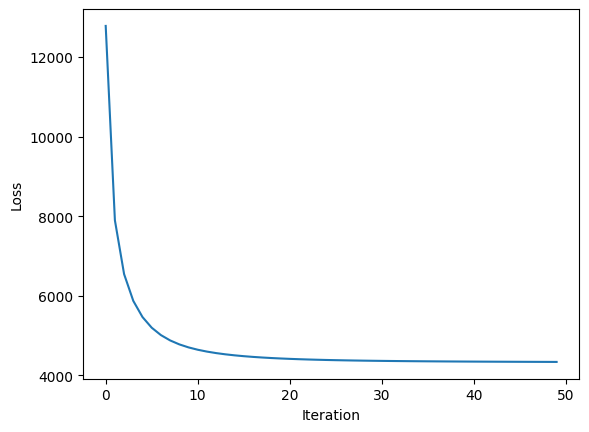

In [205]:
import matplotlib.pyplot as plt

# Loss decreases during training
plt.plot(losses)
plt.xlabel('Iteration')
plt.ylabel('Loss');

## 🔮 Try the trained model

Give context and ask the model to predict the missing word.

In [206]:
context = ['the', 'dog', 'the', 'ball']
context_idxs = torch.tensor([word_to_ix[w] for w in context], dtype=torch.long)

ix_to_word = {ix: word for word, ix in word_to_ix.items()}

# What words are in the context?
[ix_to_word[idx.item()] for idx in context_idxs]

['the', 'dog', 'the', 'ball']

Predict:

In [207]:
# Convert log-probs to probabilities and take the most likely word
predicted_ix = torch.exp(model(context_idxs)).argmax(dim=1).item()
ix_to_word[predicted_ix]

'caught'

more predictions:

In [208]:
contexts = [
    ['the', 'cat', 'at', 'the'],
    ['the', 'cat', 'the', 'cat'],
    ['the', 'cat', 'with', 'the'],
    ['the', 'rabbit', 'the', 'carrot'],
    ['the', 'mouse', 'near', 'the'],
    ['dog', 'played', 'the', 'stick'],
]

model.eval()  # switch to evaluation mode

for context in contexts:

    # Convert words → indices
    context_idxs = torch.tensor(
        [word_to_ix[w] for w in context],
        dtype=torch.long
    )

    # Forward pass (no gradient needed)
    with torch.no_grad():
        log_probs = model(context_idxs)
        predicted_ix = torch.exp(log_probs).argmax(dim=1).item()

    predicted_word = ix_to_word[predicted_ix]

    print(f"Context: {context}")
    print(f"Predicted word: {predicted_word}")
    print("-" * 40)

Context: ['the', 'cat', 'at', 'the']
Predicted word: meowed
----------------------------------------
Context: ['the', 'cat', 'the', 'cat']
Predicted word: caught
----------------------------------------
Context: ['the', 'cat', 'with', 'the']
Predicted word: ran
----------------------------------------
Context: ['the', 'rabbit', 'the', 'carrot']
Predicted word: ate
----------------------------------------
Context: ['the', 'mouse', 'near', 'the']
Predicted word: hid
----------------------------------------
Context: ['dog', 'played', 'the', 'stick']
Predicted word: with
----------------------------------------


## 📊 Visualizing learned word embeddings (3D with PCA)

After training, each word has a learned vector in a 7-dimensional space.
We cannot visualize 7D directly, so we use PCA to reduce it to 3D.

In [224]:
# first - define word categories
word_type = {}

# animals
for w in big_animals:
    word_type[w] = "big_animal"
for w in small_animals:
    word_type[w] = "small_animal"

# objects
for w in objects_on:
    word_type[w] = "object_on"
for w in objects_with:
    word_type[w] = "object_with"
for w in small_animal_objects:
    word_type[w] = "food"

# verbs
for w in general_verbs:
    word_type[w] = "general_verb"
for w in dog_only_verbs + cat_only_verbs + small_animal_verbs:
    word_type[w] = "animal_specific_verb"
for w in big_animal_object_verbs + small_animal_object_verbs:
    word_type[w] = "interaction_verb"

In [ ]:
import plotly.graph_objs as go
from sklearn.decomposition import PCA

word_vectors = model.embeddings.weight.detach().numpy()

pca = PCA(n_components=3)
reduced = pca.fit_transform(word_vectors)

# Map categories to colors (Plotly-style colors)
category_colors = {
    "big_animal": "blue",
    "small_animal": "cyan",
    "object_on": "green",
    "object_with": "lime",
    "food": "orange",
    "general_verb": "red",
    "animal_specific_verb": "purple",
    "interaction_verb": "brown",
    "unknown": "gray"
}

# Assign color per word
colors = [
    category_colors.get(word_type.get(word, "unknown"), "gray")
    for word in word_to_ix.keys()
]

# Bigger figure control
fig = go.Figure(data=[go.Scatter3d(
    x=reduced[:, 0],
    y=reduced[:, 1],
    z=reduced[:, 2],
    mode='markers+text',
    text=list(word_to_ix.keys()),
    textposition="top center",
    marker=dict(
        size=6,
        color=colors,
        opacity=0.85
    )
)])

fig.update_layout(
    title="3D Word Embeddings Visualization (Colored by Type)",
    width=1000,   # control width
    height=800,   # control height
    margin=dict(l=0, r=0, b=0, t=40),
    scene=dict(
        xaxis_title="PC 1",
        yaxis_title="PC 2",
        zaxis_title="PC 3"
    )
)

fig.show()

## 📉 2D visualization with Matplotlib

We can also project embeddings into 2D for a simpler static plot.

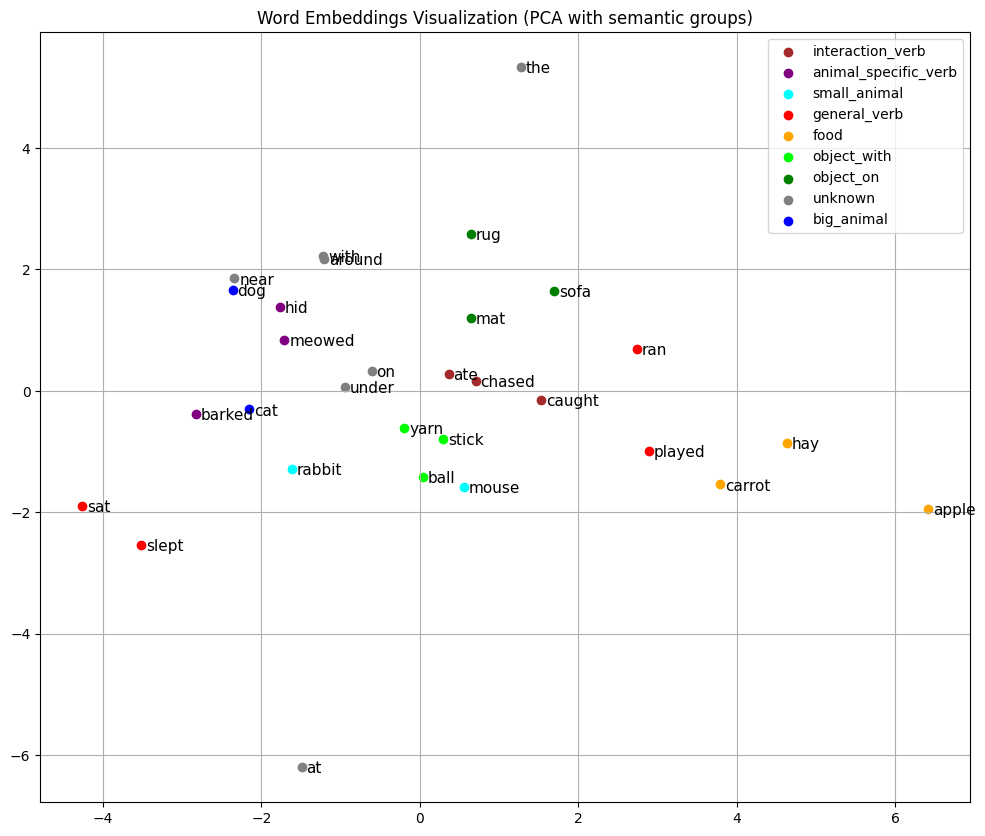

In [229]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# assign colors per category
colors = {
    "big_animal": "blue",
    "small_animal": "cyan",
    "object_on": "green",
    "object_with": "lime",
    "food": "orange",
    "general_verb": "red",
    "animal_specific_verb": "purple",
    "interaction_verb": "brown",
    "unknown": "gray"
}

pca = PCA(n_components=2)
reduced = pca.fit_transform(word_vectors)

plt.figure(figsize=(12, 10))

# To avoid duplicate legend entries
plotted_categories = set()

for i, label in enumerate(word_to_ix.keys()):
    x, y = reduced[i]

    category = word_type.get(label, "unknown")
    color = colors[category]

    # scatter point (only first time per category is labeled in legend)
    if category not in plotted_categories:
        plt.scatter(x, y, color=color, label=category)
        plotted_categories.add(category)
    else:
        plt.scatter(x, y, color=color)

    # word label
    plt.text(x + 0.06, y - 0.1, label, fontsize=11)

plt.title("Word Embeddings Visualization (PCA with semantic groups)")
plt.grid(True)

# show legend
plt.legend()

plt.show()

## 📊 3D Plot with hover info (category + neighbors)

In [230]:
import numpy as np
import plotly.graph_objs as go
from sklearn.decomposition import PCA
import torch
import torch.nn.functional as F

word_vectors = model.embeddings.weight.detach().numpy()

pca = PCA(n_components=3)
reduced = pca.fit_transform(word_vectors)

ix_to_word = {ix: word for word, ix in word_to_ix.items()}

# --- compute neighbors using cosine similarity ---
def get_neighbors(word, topk=3):
    idx = word_to_ix[word]
    vec = model.embeddings.weight[idx]

    cos_sim = F.cosine_similarity(
        vec.unsqueeze(0),
        model.embeddings.weight
    )

    best = torch.topk(cos_sim, topk + 1).indices.tolist()

    return [ix_to_word[i] for i in best if i != idx]

# --- color mapping ---
category_colors = {
    "big_animal": "blue",
    "small_animal": "cyan",
    "object_on": "green",
    "object_with": "lime",
    "food": "orange",
    "general_verb": "red",
    "animal_specific_verb": "purple",
    "interaction_verb": "brown",
    "unknown": "gray"
}

colors = [
    category_colors.get(word_type.get(word, "unknown"), "gray")
    for word in word_to_ix.keys()
]

# --- hover text ---
hover_texts = []
for word in word_to_ix.keys():
    category = word_type.get(word, "unknown")
    neighbors = get_neighbors(word)

    hover_texts.append(
        f"Word: {word}<br>"
        f"Category: {category}<br>"
        f"Neighbors: {', '.join(neighbors)}"
    )

# --- plot ---
fig = go.Figure(data=[go.Scatter3d(
    x=reduced[:, 0],
    y=reduced[:, 1],
    z=reduced[:, 2],
    mode='markers+text',
    text=list(word_to_ix.keys()),
    textposition="top center",
    hovertext=hover_texts,
    hoverinfo="text",
    marker=dict(
        size=6,
        color=colors,
        opacity=0.85
    )
)])

fig.update_layout(
    title="3D Word Embeddings (Category + Nearest Neighbors)",
    width=1000,
    height=800,
    margin=dict(l=0, r=0, b=0, t=40),
    scene=dict(
        xaxis_title="PC 1",
        yaxis_title="PC 2",
        zaxis_title="PC 3"
    )
)

fig.show()

## 📍 Nearest Neighbours

In [231]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

ix_to_word = {ix: word for word, ix in word_to_ix.items()}

def most_similar(word, vectors, word_to_ix, topn=5):
    idx = word_to_ix[word]
    query = vectors[idx].reshape(1, -1)
    sims = cosine_similarity(query, vectors)[0]
    sorted_ix = np.argsort(-sims)
    return [(ix_to_word[i], sims[i]) for i in sorted_ix[1:topn+1]]

most_similar("cat", word_vectors, word_to_ix)

[('near', np.float32(0.6057408)),
 ('around', np.float32(0.5810697)),
 ('sat', np.float32(0.5580077)),
 ('ball', np.float32(0.47128922)),
 ('hid', np.float32(0.43274683))]

In [237]:
word_vectors.shape

(30, 7)

In [232]:
most_similar("dog", word_vectors, word_to_ix)

[('near', np.float32(0.5305625)),
 ('under', np.float32(0.46778893)),
 ('barked', np.float32(0.3896212)),
 ('rabbit', np.float32(0.38914192)),
 ('on', np.float32(0.3447646))]

In [235]:
most_similar("slept", word_vectors, word_to_ix)

[('sat', np.float32(0.82607985)),
 ('at', np.float32(0.7094759)),
 ('barked', np.float32(0.6771149)),
 ('rabbit', np.float32(0.6451807)),
 ('stick', np.float32(0.62126184))]

In [240]:
most_similar("carrot", word_vectors, word_to_ix)

[('hay', np.float32(0.8693486)),
 ('apple', np.float32(0.7187696)),
 ('chased', np.float32(0.6271535)),
 ('caught', np.float32(0.5953158)),
 ('ball', np.float32(0.4656394))]

* Despite observing some meaningful separation and clustering in 2D and 3D visualizations, cosine similarity on this dataset does not always produce strongly meaningful results.

* Word embeddings reflect **co-occurrence structure**. In small synthetic corpora, high-frequency function words (e.g., prepositions) can dominate the similarity space, causing semantically unrelated words to appear closer than expected.

* Cosine similarity provides a more precise view of learned relationships than visualization alone, but on small datasets it still mainly reflects **statistical co-occurrence patterns rather than deep semantic understanding**.
